In [20]:
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter
import matplotlib.ticker as mtick


In [5]:
DATASET_PATH_MADRID = 'datasets_groundtruths/Madrid/gt/'
DATASET_PATH_LP = 'datasets_groundtruths/LP/gt/'

In [6]:
total_counts = Counter()

for filename in os.listdir(DATASET_PATH_MADRID):
    if filename.endswith('.npy'):
        data = np.load(os.path.join(DATASET_PATH_MADRID, filename))

        # Count unique values in the data
        unique, counts = np.unique(data, return_counts=True)
        value_counts = dict(zip(unique, counts))

        # Update the total counts
        #print(filename)
        total_counts.update(value_counts)

In [7]:
total_counts.pop(0,None) #remove uncategorized pixels

7212466

In [8]:
total_counts1_sorted = dict(sorted(total_counts.items(), key=lambda item: item[0]))

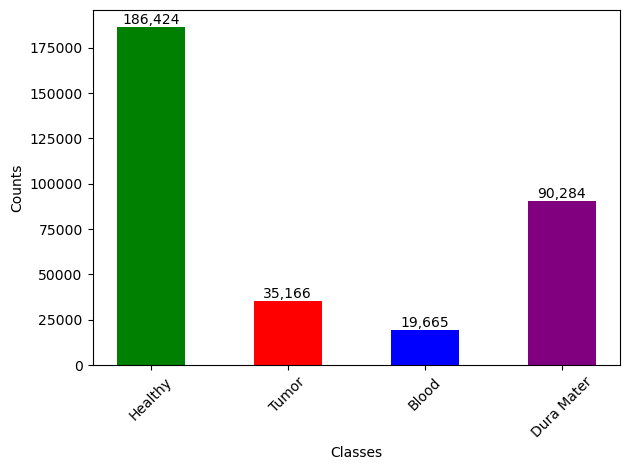

In [9]:
x_labels = ['Healthy', 'Tumor', 'Blood', 'Dura Mater']
y_values = list(total_counts1_sorted.values())
colors = ['green', 'red', 'blue', 'purple']

bars = plt.bar(x_labels, y_values, color=colors, width=0.5)
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f"{int(height):,}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [10]:
total_counts = Counter()

for filename in os.listdir(DATASET_PATH_LP):
    if filename.endswith('.npy'):
        data = np.load(os.path.join(DATASET_PATH_LP, filename))

        # Count unique values in the data
        unique, counts = np.unique(data, return_counts=True)
        value_counts = dict(zip(unique, counts))

        # Update the total counts
        #print(filename)
        total_counts.update(value_counts)

In [11]:
total_counts.pop(0,None) #remove uncategorized pixels

13157399

In [12]:
total_counts2_sorted = dict(sorted(total_counts.items(), key=lambda item: item[0]))

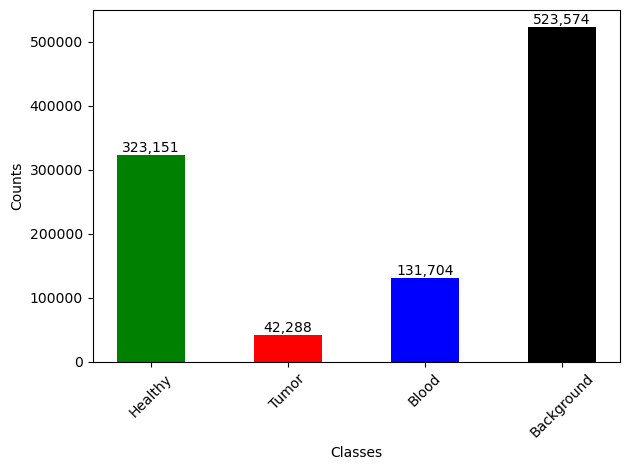

In [13]:
x_labels = ['Healthy', 'Tumor', 'Blood', 'Background']
y_values = list(total_counts2_sorted.values())
colors = ['green', 'red', 'blue', 'black']

bars = plt.bar(x_labels, y_values, color=colors, width=0.5)
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f"{int(height):,}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [14]:
x_labels = ['Healthy', 'Tumor', 'Blood', 'DM/Background']

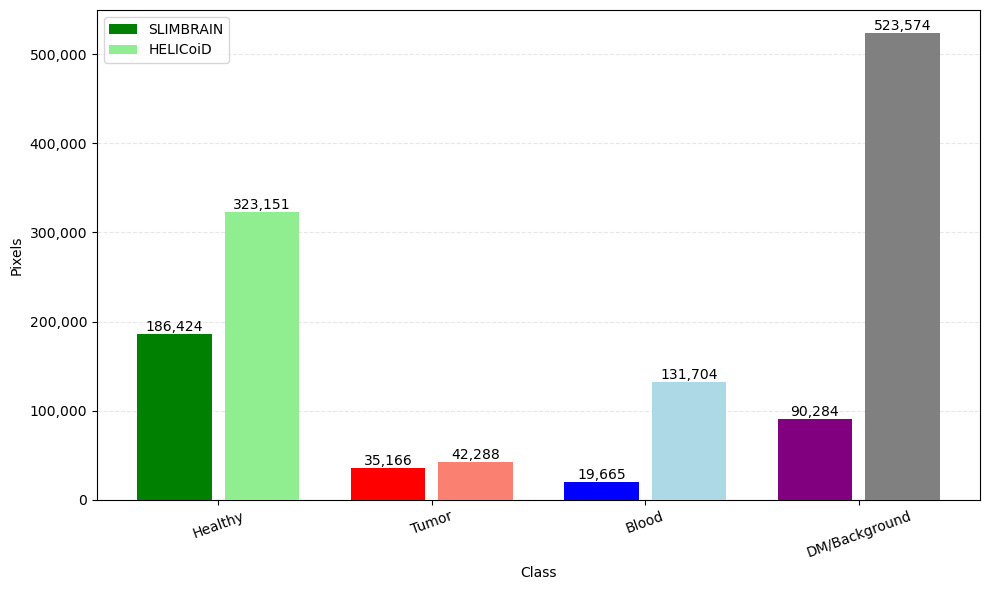

In [21]:
y_values_1 = list(total_counts1_sorted.values())
y_values_2 = list(total_counts2_sorted.values())

x = np.arange(len(x_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2 - 0.03, y_values_1, width, label='SLIMBRAIN', color=['green', 'red', 'blue', 'purple'], zorder=3)
bars2 = ax.bar(x + width/2 + 0.03, y_values_2, width, label='HELICoiD', color=['lightgreen', 'salmon', 'lightblue', 'grey'], zorder=3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{int(height):,}", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{int(height):,}", ha='center', va='bottom')


ax.set_xlabel('Class')
ax.set_ylabel('Pixels')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=20)
ax.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.8, zorder=0)
ax.legend()
plt.tight_layout()
plt.savefig("grouped_bar_plot.png", dpi=1200, bbox_inches='tight', transparent=True)
plt.show()